In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
veri_maas = {
    'Seviye': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Maas': [45, 50, 60, 80, 110, 150, 200, 300, 500, 1000]
}
df = pd.DataFrame(veri_maas)
X = df[['Seviye']]
y = df['Maas']

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

rf_reg.fit(X, y)

tahmin_orman = rf_reg.predict([[6.5]])
print(f"Random Forest'ın 6.5 Seviyesi İçin Maaş Teklifi: {tahmin_orman[0]:.2f} Bin TL")

Random Forest'ın 6.5 Seviyesi İçin Maaş Teklifi: 168.20 Bin TL


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


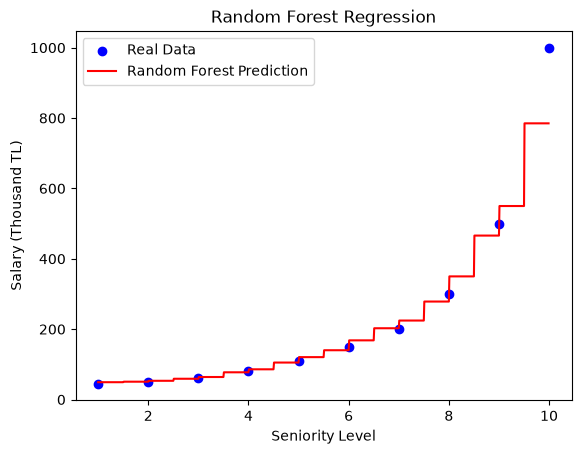

In [4]:
X_grid = np.arange(min(X['Seviye']), max(X['Seviye']), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

plt.scatter(X, y, color='blue', label='Real Data')
plt.plot(X_grid, rf_reg.predict(X_grid), color='red', label='Random Forest Prediction')

plt.title('Random Forest Regression')
plt.xlabel('Seniority Level')
plt.ylabel('Salary (Thousand TL)')
plt.legend()
plt.show()

In [6]:
tahminler_rf = rf_reg.predict(X)

# 1. MAE (Ortalama Mutlak Hata)
mae = mean_absolute_error(y, tahminler_rf)

# 2. MSE (Hata Kareler Ortalaması)
mse = mean_squared_error(y, tahminler_rf)

# 3. RMSE (MSE'nin Karekökü)
rmse = np.sqrt(mse)

# 4. R-Kare (Başarı Skoru)
r2 = r2_score(y, tahminler_rf)

print(f"MAE  (Ortalama Sapma): {mae:.2f} Bin TL")
print(f"MSE  (Karesel Ceza):   {mse:.2f}")
print(f"RMSE (Kök Hata):       {rmse:.2f} Bin TL")
print(f"R-Kare (Başarı Notu):  {r2:.4f}")

MAE  (Ortalama Sapma): 29.64 Bin TL
MSE  (Karesel Ceza):   4799.82
RMSE (Kök Hata):       69.28 Bin TL
R-Kare (Başarı Notu):  0.9405
